# **ARIMA (Autoregressive Integrated Moving Average)**

O ARIMA (Autoregressive Integrated Moving Average) é um dos modelos mais clássicos e fundamentais para a análise e previsão de séries temporais estatísticas. Desenvolvido por George Box e Gwilym Jenkins, o modelo é denotado pela sigla ARIMA(p, d, q), em que cada letra representa uma componente matemática específica para capturar a dinâmica temporal dos dados.

## **Estrutura e Componentes do ARIMA($p, d, q$)**

O modelo é a união de três partes:

## **1. AR ($p$) — Autoregressive (Autorregressivo)**

* **Conceito:** Explica o valor atual com base nos seus próprios valores passados (lags).

*  **Parâmetro $p$:** Representa a quantidade de defasagens (lags) passadas incluídas na equação.

 * Equação do AR($p$):$$Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \dots + \phi_p Y_{t-p} + \epsilon_t$$

## **2. I ($d$) — Integrated (Integrado)**

*  **Conceito:** Representa a quantidade de diferenciações necessárias para tornar a série temporal estacionária (com média e variação constantes ao longo do tempo).
 * **Parâmetro $d$:** É o grau de diferenciação.
 * $d = 0$: A série já é estacionária.
 * $d = 1$: Aplica-se a primeira diferença: $\Delta Y_t = Y_t - Y_{t-1}$.
 * $d = 2$: Diferencia-se a série duas vezes se a tendência persistir.

## **3. MA ($q$) — Moving Average (Média Móvel)**

* **Conceito**: Modela a dependência entre a observação atual e os erros de previsão (choques ou ruídos aleatórios) ocorridos no passado.

* **Parâmetro $q$:** Quantidade de erros passados considerados no modelo.

* **Equação do MA($q$):**

$$Y_t = c + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \dots + \theta_q \epsilon_{t-q}$$


## 4. **Equação Geral do ARIMA($p,d,q$)**

A Equação Geral do ARIMA($p,d,q$).  Combinando as três partes sobre a série já diferenciada $y_t = \Delta^d Y_t$:$$y_t = c + \sum_{i=1}^{p} \phi_i y_{t-i} + \epsilon_t + \sum_{j=1}^{q} \theta_j \epsilon_{t-j}$$Onde $\epsilon_t$ representa o erro de estimativa no tempo $t$, assumido como um ruído branco ($\epsilon_t \sim \mathcal{N}(0, \sigma^2)$).

# **Importando as bibliotecas**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from  matplotlib.pylab import rcParams
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
rcParams['figure.figsize'] =15,7

# **Criando a série temporal**





In [6]:
#Série Modelo ARIMA
import statsmodels.api as sm
np.random.seed(42)
n_samples = 300

phi = 0.7  # Parâmetro AR(1)
theta = -0.4  # Parâmetro MA(1)
ruido = np.random.normal(loc=0, scale=1.0, size=n_samples)

# Geração do processo ARMA(1, 1) estacionário
arma_process = np.zeros(n_samples)
for t in range(1, n_samples):
    arma_process[t] = (
        phi * arma_process[t - 1] + ruido[t] + theta * ruido[t - 1]
    )

# Integração (d=1) + Tendência determinística para simular série não-estacionária
tendencia = np.linspace(10, 50, n_samples)
serie_sintetica = np.cumsum(arma_process) + tendencia

# Criação do DataFrame com índice de datas diárias
datas = pd.date_range(start='2024-01-01', periods=n_samples, freq='D')
serie_arima = pd.Series(serie_sintetica, index=datas, name='Valor_Sintetico')

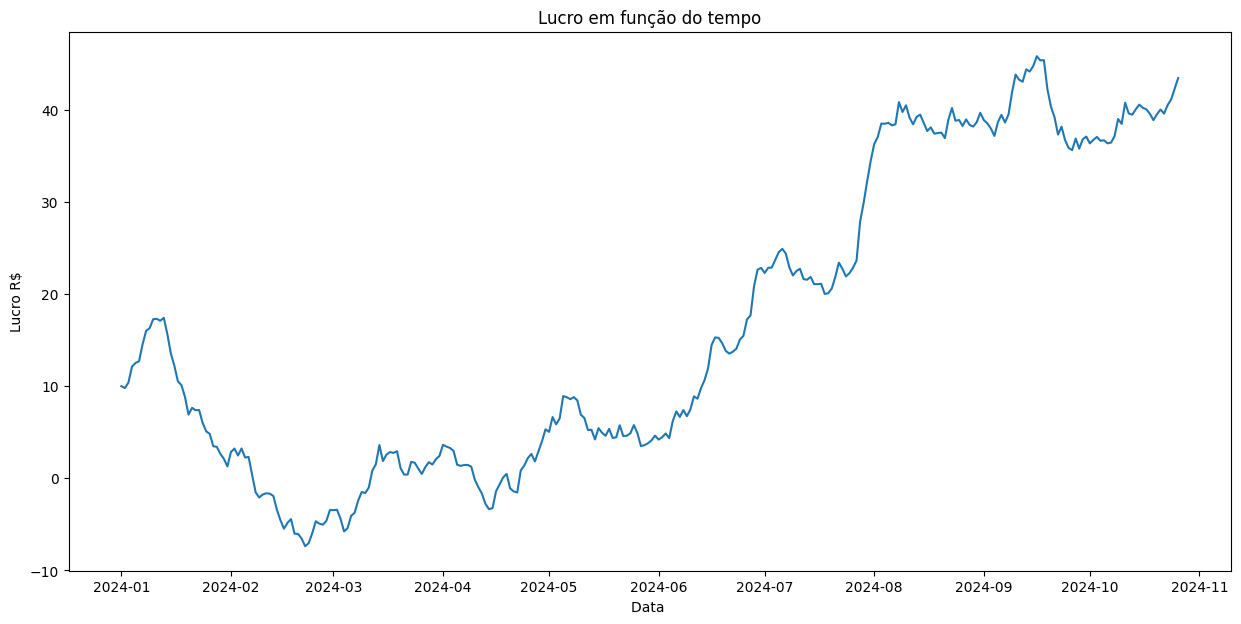

In [7]:
plt.plot(serie_arima)
plt.title('Lucro em função do tempo')
plt.xlabel('Data ')
plt.ylabel('Lucro R$')
plt.show()

## **Definição da série temporal**

# **Estudo da Série temporal**

Nesta seção será realizdo o estudo da série temporal, onde serão avaliados:

* Decomposição

* Normalidade da série.
  * Teste de Shapiro-Wilk
  * Grafico QQ_plot
  * Histograma
* Estacionariadade (Teste KPSS)
* Funções de auto correlação (ACF e PACF)

### **Decomposicao**

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposicao = seasonal_decompose(serie_arima, model='additive')

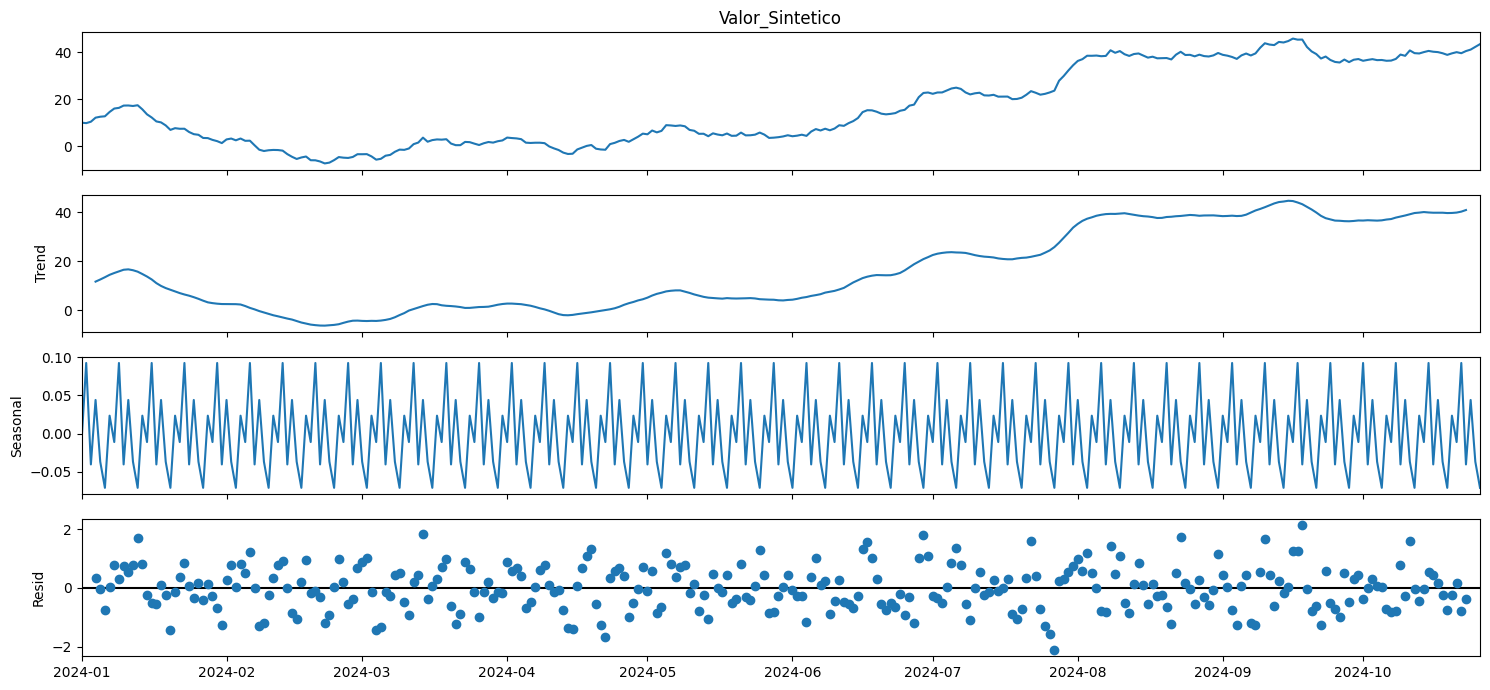

In [9]:
decomposicao.plot()
plt.show()

## **Normalidade da série.**

### **Hipóteses do Teste de Shapiro-Wilk**


O teste avalia duas hipóteses concorrentes:
* **Hipótese Nula ($H_0$):** Os dados seguem uma distribuição normal.
* **Hipótese Alternativa ($H_1$):** Os dados não seguem uma distribuição normal.

**Como Interpretar o P-Valor (p-value)**

* **Se $p \ge 0,05$:** Não há evidências para rejeitar $H_0$. Conclui-se que os resíduos do modelo são aproximadamente normais (modelo validado quanto à normalidade).
* **Se $p < 0,05$:** Rejeita-se $H_0$. Os resíduos não seguem uma distribuição normal, indicando possíveis problemas no modelo (como presenças de outliers ou heterocedasticidade

In [14]:
import scipy.stats as stats

e,p_valor =stats.shapiro(serie_arima)
print('Estatistica de teste = %.3f, p-valor = %.3f' % (e,p_valor))

Estatistica de teste = 0.877, p-valor = 0.000


In [16]:
if p_valor >= 0.05:
  print('Não há evidências para rejeitar a hipótese nula. Os dados seguem uma distribuição normal.')
else:
  print('Rejeita-se a hipótese nula. Os dados não seguem uma distribuição normal.')

Rejeita-se a hipótese nula. Os dados não seguem uma distribuição normal.


### **QQ_plot**

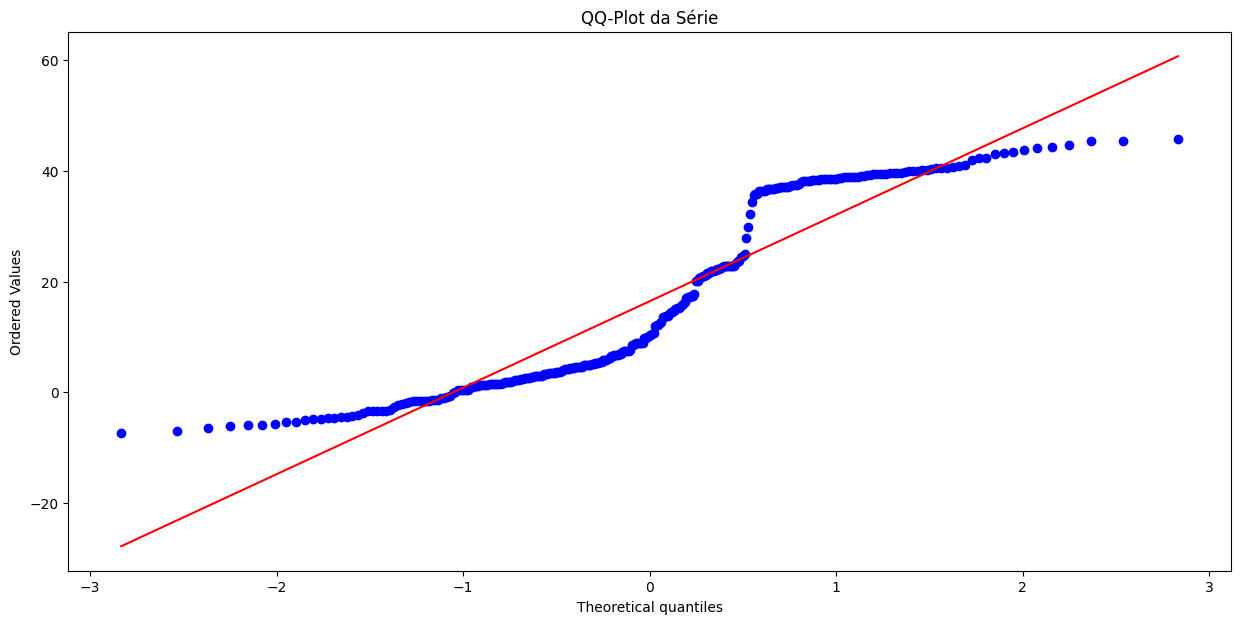

In [10]:
import scipy.stats as stats
stats.probplot(serie_arima, dist='norm', plot=plt)
plt.title('QQ-Plot da Série')
plt.show()


### **Histrograma da série**




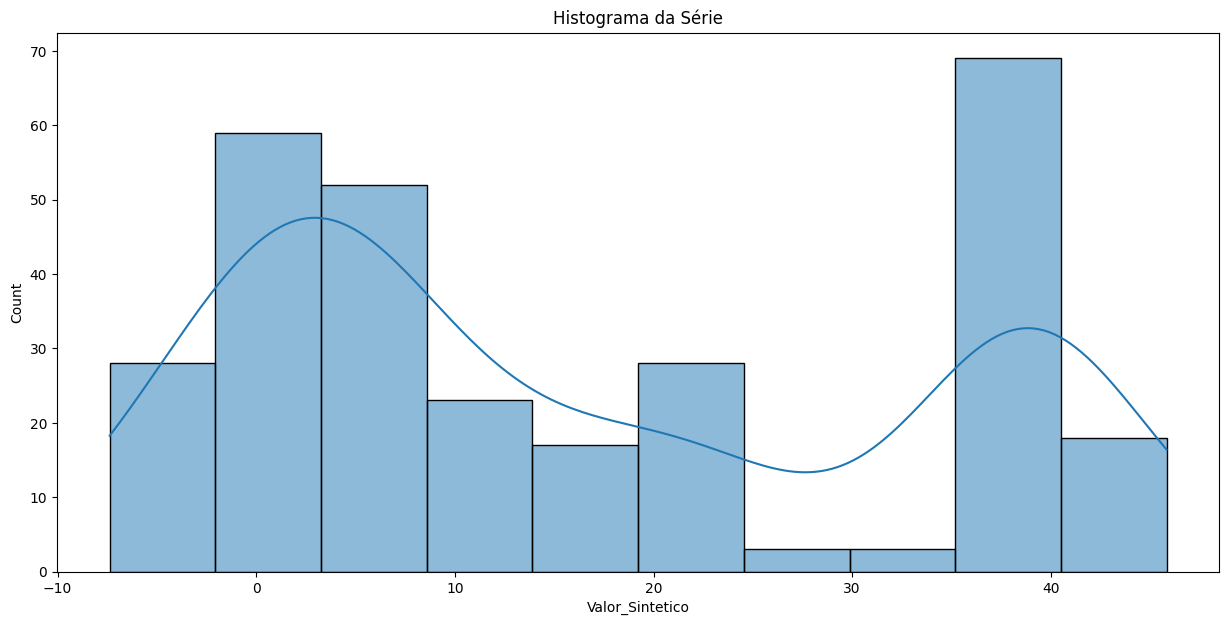

In [11]:
import seaborn as sns
sns.histplot(serie_arima, kde=True)
plt.title('Histograma da Série')
plt.show()


## **Estacionaridade da série -Modelo Autoregressivo**

O teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin) é um teste estatístico utilizado em séries temporais para verificar se os dados são estacionários em torno de uma média ou de uma tendência determinística.

**Como o Teste Funciona**
* **Hipótese Nula (H₀):** A série temporal é estacionária (em nível ou em tendência).
* **Hipótese Alternativa (H₁):** A série temporal não é estacionária (possui raiz unitária

**Interpretação dos Resultados**
* **p-valor > 0,05** (ou estatística menor que o valor crítico): Você não rejeita a hipótese nula. Os dados indicam que a série é estacionária.
* **p-valor ≤ 0,05** (ou estatística maior que o valor crítico): Você rejeita a hipótese nula. Há fortes evidências de que a série não é estacionária

In [17]:
import statsmodels.tsa.stattools

In [19]:
result_kpss = statsmodels.tsa.stattools.kpss(serie_arima)
print('Estatistica de teste = %.3f, p-valor = %.3f' % (result_kpss[0], result_kpss[1]))

Estatistica de teste = 2.341, p-valor = 0.010


/tmp/ipykernel_488/4294607787.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  result_kpss = statsmodels.tsa.stattools.kpss(serie_arima)
/tmp/ipykernel_488/4294607787.py:1: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_kpss = statsmodels.tsa.stattools.kpss(serie_arima)


In [20]:
if p_valor > 0.05:
    print('A série é estacionária')
else:
    print('A série não é estacionária')

A série não é estacionária


##  **Estudo da autocorrelaçao (ACF e PACF)**

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

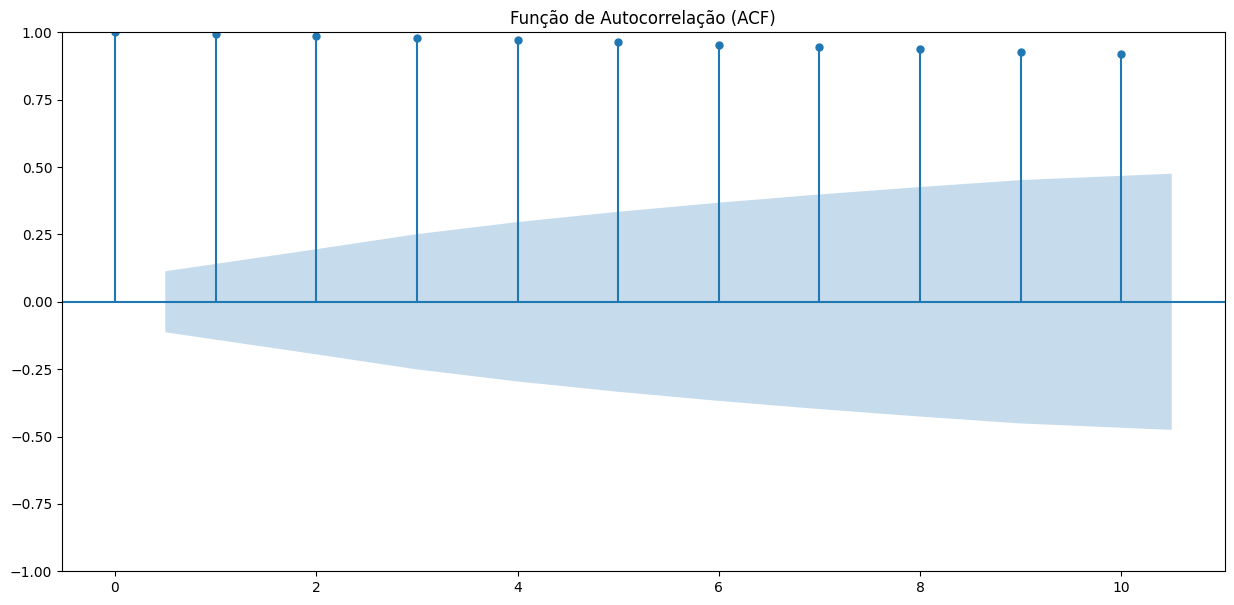

In [23]:
plot_acf(serie_arima ,lags=10, color='#1f77b4', title='Função de Autocorrelação (ACF)')
plt.show()

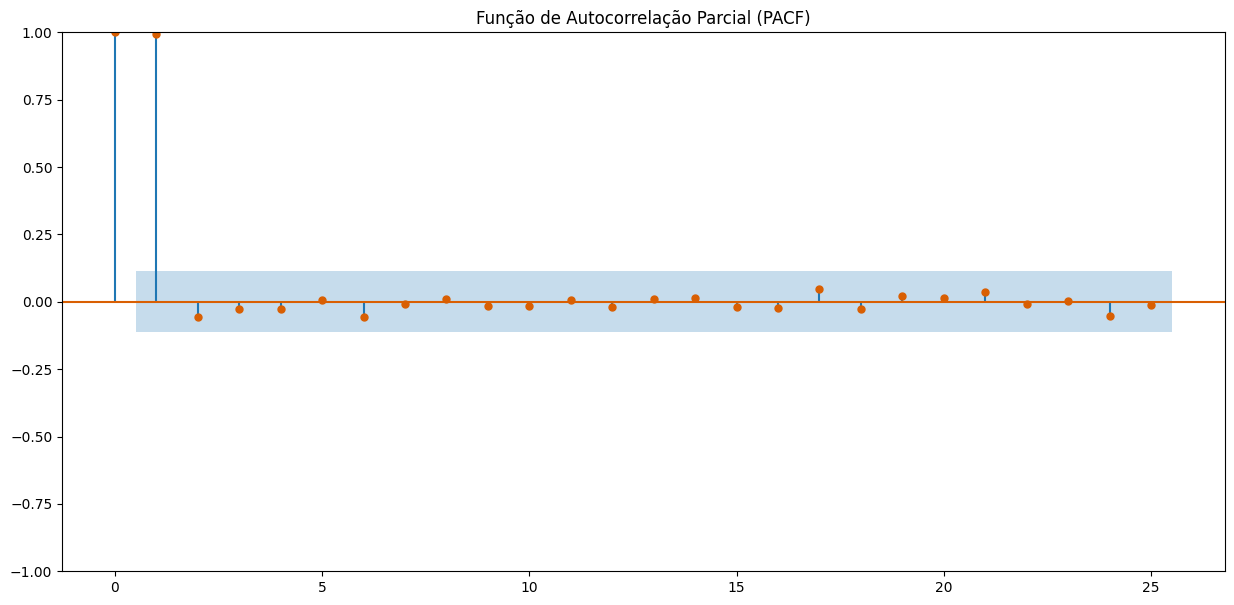

In [25]:
plot_pacf(serie_arima, lags=25, color='#d95f02', title='Função de Autocorrelação Parcial (PACF)')
plt.show()

# **Implementação do modelo  ARIMA**

* Definição do modelo
* Estudo do resíduo
* Aplicação do modelo.

## **Definição do modelo ARIMA**

In [26]:
from statsmodels.tsa.arima.model import ARIMA

In [28]:
modelo_arima = ARIMA( serie_arima , order=(1, 1, 1))

In [44]:
modelo_arima_result = modelo_arima.fit()

In [45]:
print(modelo_arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:        Valor_Sintetico   No. Observations:                  300
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -418.939
Date:                Thu, 17 Sep 2026   AIC                            843.879
Time:                        23:02:09   BIC                            854.980
Sample:                    01-01-2024   HQIC                           848.322
                         - 10-26-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7515      0.117      6.408      0.000       0.522       0.981
ma.L1         -0.5300      0.153     -3.457      0.001      -0.831      -0.229
sigma2         0.9645      0.069     14.036      0.0

## **Estudo do resíduo**

In [46]:
residuos_modelo_arima = modelo_arima_result.resid

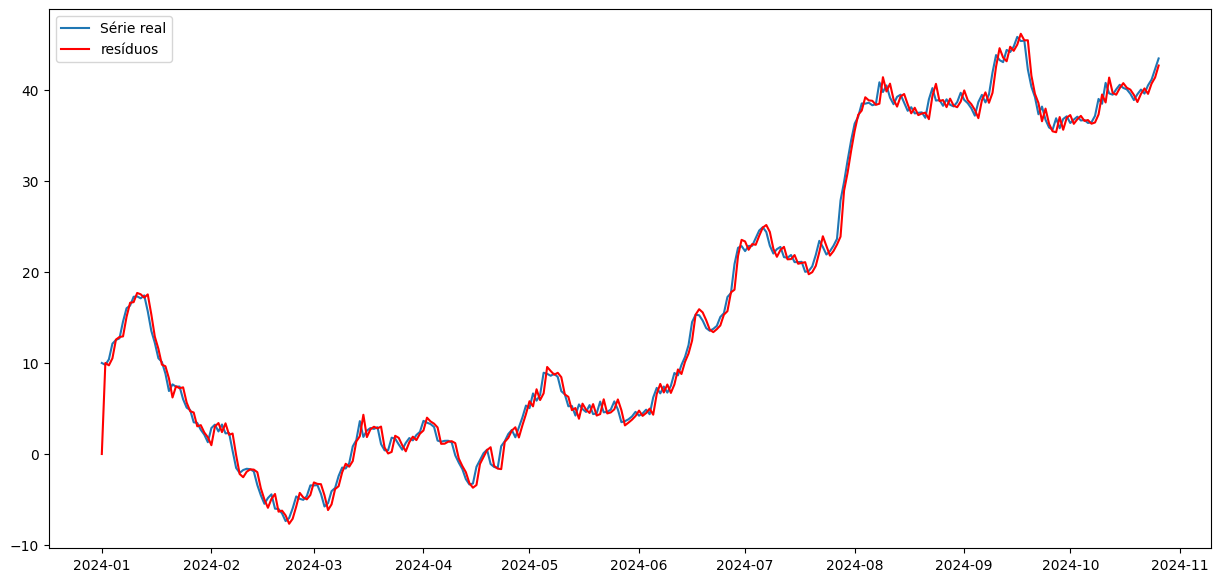

In [47]:
plt.plot(serie_arima, label  ="Série real")
plt.plot(serie_arima-residuos_modelo_arima, color ='red', label ="resíduos")
plt.legend(loc = 'best')
plt.show()

###  **Normalidade do resíduo**

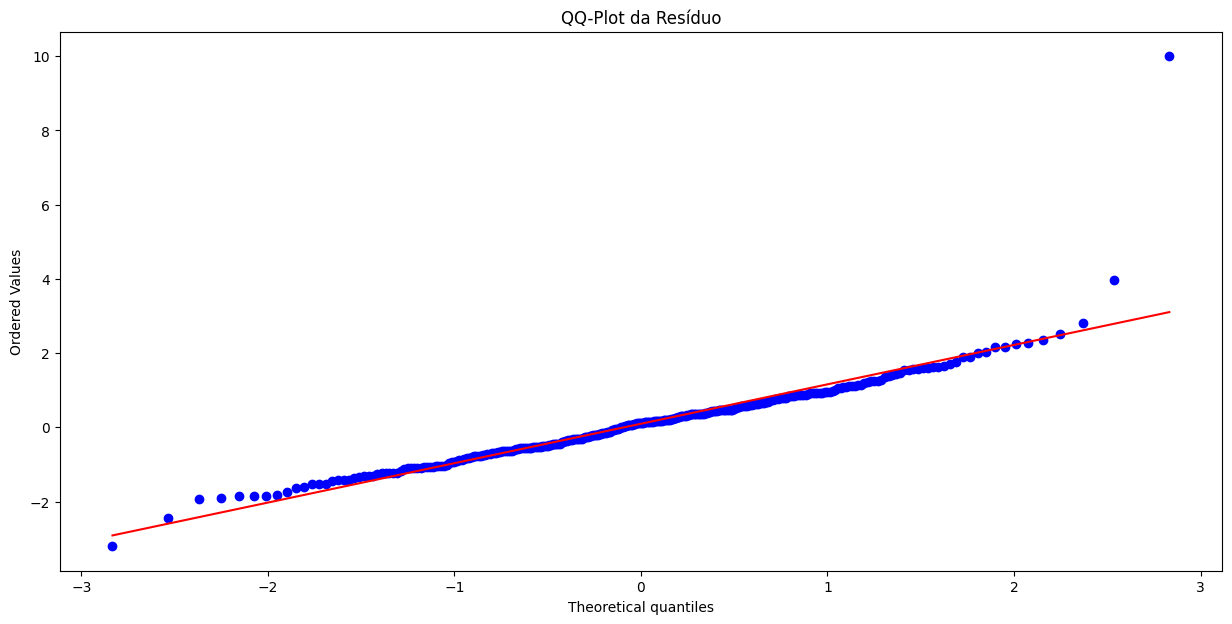

In [48]:
import scipy.stats as stats
stats.probplot(residuos_modelo_arima, dist='norm', plot=plt)
plt.title('QQ-Plot da Resíduo')
plt.show()

In [36]:
e,p_valor =stats.shapiro(residuos_modelo_arima)
print('Estatistica de teste = %.3f, p-valor = %.3f' % (e,p_valor))

Estatistica de teste = 0.874, p-valor = 0.000


In [37]:
if p_valor >= 0.05:
  print('Não há evidências para rejeitar a hipótese nula. Os dados seguem uma distribuição normal.')
else:
  print('Rejeita-se a hipótese nula. Os dados não seguem uma distribuição normal.')

Rejeita-se a hipótese nula. Os dados não seguem uma distribuição normal.


### **Autocorrelação dos resíduos**

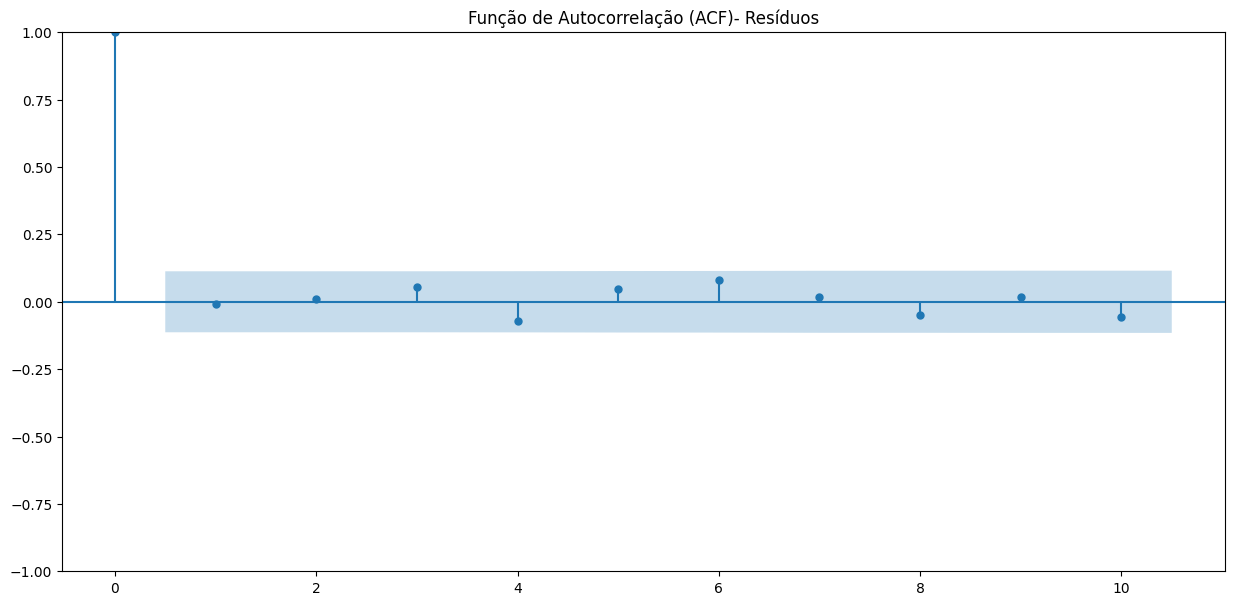

In [38]:
plot_acf(residuos_modelo_arima,lags=10, color='#1f77b4', title='Função de Autocorrelação (ACF)- Resíduos')
plt.show()

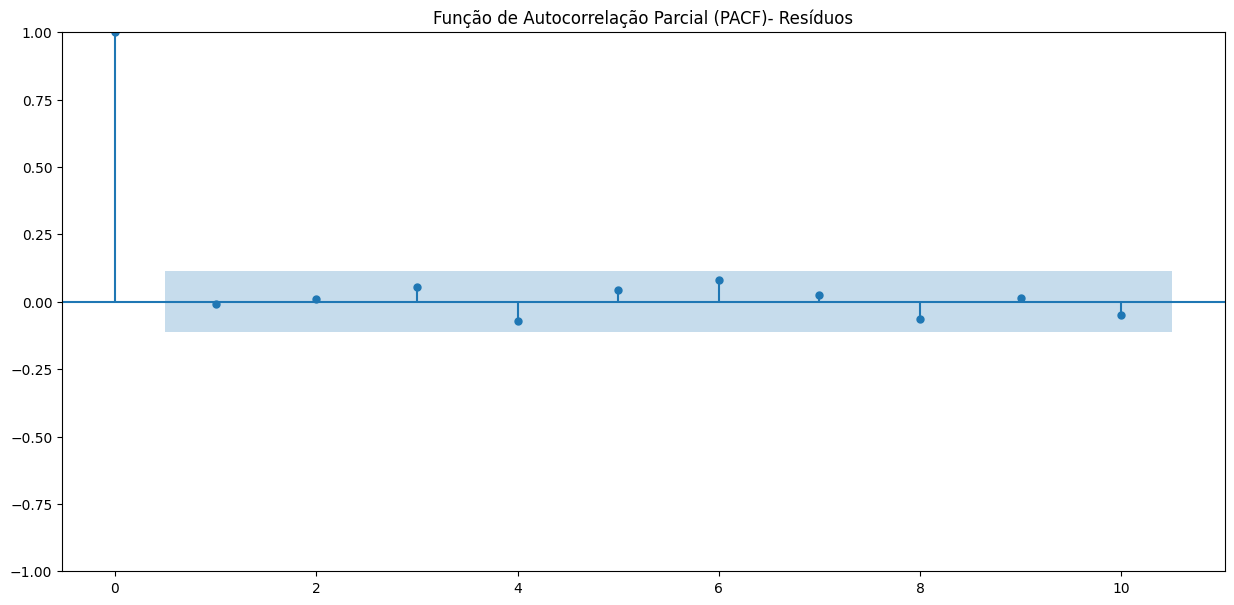

In [40]:
plot_pacf(residuos_modelo_arima,lags=10, color='#1f77b4', title='Função de Autocorrelação Parcial (PACF)- Resíduos')
plt.show()

# **Aplicando o modelo médiamóvel**

In [41]:
modelo_arima_result.fittedvalues

,0
2024-01-01,0.000000
2024-01-02,10.000003
2024-01-03,9.740942
2024-01-04,10.510799
2024-01-05,12.570874
...,...
2024-10-22,40.164803
2024-10-23,39.567110
2024-10-24,40.691052
2024-10-25,41.365695


In [42]:
previsao_arima = modelo_arima_result.forecast(10)

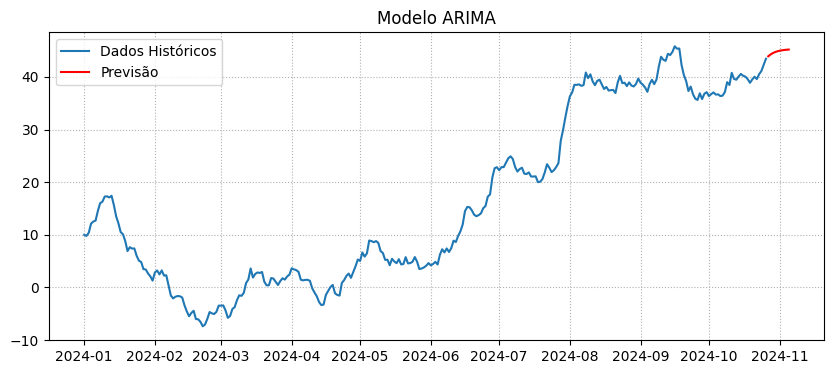

In [43]:
plt.figure(figsize=(10, 4))
plt.plot(serie_arima, label='Dados Históricos')
plt.plot(previsao_arima , color='red', label='Previsão')
plt.title('Modelo ARIMA')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

## **Criando os intervalor de confiança para as previsões**

In [50]:
previsao_modelo_arima = modelo_arima_result.get_forecast(steps=7).summary_frame()

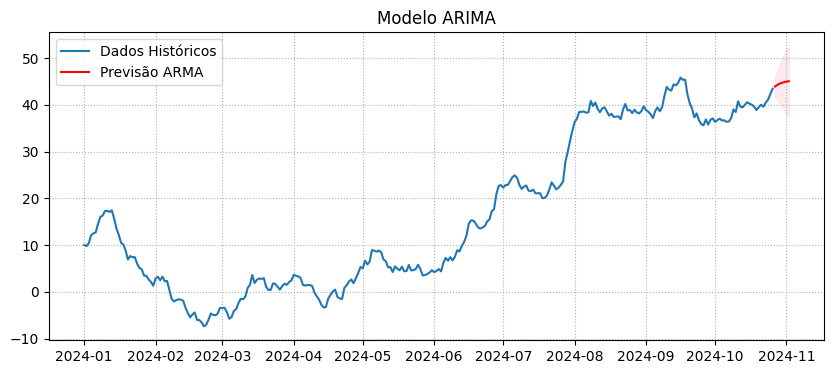

In [51]:
plt.figure(figsize=(10, 4))
plt.plot(serie_arima, label='Dados Históricos')
plt.plot(previsao_modelo_arima['mean'], color='red', label='Previsão ARMA')
plt.fill_between(previsao_modelo_arima.index,previsao_modelo_arima['mean_ci_lower'], previsao_modelo_arima['mean_ci_upper'], color='pink', alpha=0.3)
plt.title('Modelo ARIMA')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()